In [11]:
# Libraries

import numpy as np
from pathlib import Path
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img


/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
# Functions

def create_augmented_images(orig_imgs_path, new_imgs_path, num_imgs_to_create):
    '''
    Function to create num_imgs_to_create new images from all images in dir orig_imgs_path and save new images to new_imgs_path.

    Adapted from: https://pyimagesearch.com/2019/07/08/keras-imagedatagenerator-and-data-augmentation/
    '''

    imgs_to_gen = num_imgs_to_create
    root_dir = Path(orig_imgs_path)
    output_dir = new_imgs_path
    
    img_files = [f for f in root_dir.rglob('*.png') if f.is_file()]
    
    for img_file in img_files:
        img_prefix = str(img_file).split('/')[-1].strip('.png')
        
        #print(f"[INFO] loading image {img_prefix}.png...")
        image = load_img(img_file)
        image = img_to_array(image)
        image = np.expand_dims(image, axis=0)
        
        # Construct the image generator for data augmentation
        aug = ImageDataGenerator(
           rotation_range=15,       # rotate images by ±15 degrees
           width_shift_range=0.1,   # 10% horizontal shift
           height_shift_range=0.1,  # 10% vertical shift
           zoom_range=0.1,          # zoom in/out by 10%
           shear_range=0.1,         # apply shear transformation
           horizontal_flip=False,   # not needed
           fill_mode='nearest'      # fill missing pixels after transformations
        )
    
        # Initialize the total number of images generated thus far
        total = 0
        
        # Construct the actual Python generator
        #print(f"[INFO] generating {imgs_to_gen} augmented images...")
        imageGen = aug.flow(image, batch_size=1, save_to_dir=output_dir,
        	save_prefix=img_prefix, save_format="png")
        # Loop over examples from our image data augmentation generator
        for image in imageGen:
        	# increment our counter
        	total += 1
        	# If we have reached the specified number of examples, break from the loop
        	if total == imgs_to_gen:
        		break
    

In [8]:
# Augment training anomaly data (transistor)
create_augmented_images('/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_binary/split_before_augmentation/transistor/train/all_anomalies', 
                        '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_binary/split_before_augmentation/transistor/train/all_anomalies',
                        6)


In [7]:
# Augment holdout anomaly data (transistor)
create_augmented_images('/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_binary/split_before_augmentation/transistor/holdout/all_anomalies', 
                        '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_binary/split_before_augmentation/transistor/holdout/all_anomalies',
                        6)


In [10]:
# Multi-class transistor data augmentation (split train, validation and holdout before augmentation)

# Train images augmentation

create_augmented_images('/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/train/bent_lead', 
                        '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/train/bent_lead',
                        27)

create_augmented_images('/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/train/cut_lead', 
                        '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/train/cut_lead',
                        27)

create_augmented_images('/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/train/damaged_case', 
                        '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/train/damaged_case',
                        27)

create_augmented_images('/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/train/misplaced', 
                        '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/train/misplaced',
                        27)


In [11]:
# Validation images augmentation

create_augmented_images('/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/validation/bent_lead', 
                        '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/validation/bent_lead',
                        30)

create_augmented_images('/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/validation/cut_lead', 
                        '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/validation/cut_lead',
                        30)

create_augmented_images('/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/validation/damaged_case', 
                        '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/validation/damaged_case',
                        30)

create_augmented_images('/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/validation/misplaced', 
                        '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/validation/misplaced',
                        30)


In [12]:
# Holdout images augmentation

create_augmented_images('/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/holdout/bent_lead', 
                        '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/holdout/bent_lead',
                        20)

create_augmented_images('/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/holdout/cut_lead', 
                        '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/holdout/cut_lead',
                        20)

create_augmented_images('/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/holdout/damaged_case', 
                        '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/holdout/damaged_case',
                        20)

create_augmented_images('/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/holdout/misplaced', 
                        '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/transistor/holdout/misplaced',
                        20)


## Hazelnut: augmenting pre-split train, validation and test sets

In [8]:
# Train images augmentation

base_dir='/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/hazelnut/train'
anoms = ['crack', 'cut', 'hole', 'print']

for anom in anoms:
    create_augmented_images(os.path.join(base_dir, anom), os.path.join(base_dir, anom), 30)


In [9]:
# Validation images augmentation

base_dir='/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/hazelnut/validation'
anoms = ['crack', 'cut', 'hole', 'print']

for anom in anoms:
    create_augmented_images(os.path.join(base_dir, anom), os.path.join(base_dir, anom), 20)
    

In [10]:
# Holdout images augmentation

base_dir='/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/hazelnut/holdout'
anoms = ['crack', 'cut', 'hole', 'print']

for anom in anoms:
    create_augmented_images(os.path.join(base_dir, anom), os.path.join(base_dir, anom), 14)
    

## Leather: augmenting pre-split train, validation and test sets

In [11]:
# Train images augmentation

base_dir='/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/leather/train'
anoms = ['color', 'cut', 'fold', 'glue', 'poke']

for anom in anoms:
    create_augmented_images(os.path.join(base_dir, anom), os.path.join(base_dir, anom), 18)
    

In [12]:
base_dir='/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/leather/validation'
anoms = ['color', 'cut', 'fold', 'glue', 'poke']

for anom in anoms:
    create_augmented_images(os.path.join(base_dir, anom), os.path.join(base_dir, anom), 14)


In [13]:
base_dir='/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/leather/holdout'
anoms = ['color', 'cut', 'fold', 'glue', 'poke']

for anom in anoms:
    create_augmented_images(os.path.join(base_dir, anom), os.path.join(base_dir, anom), 8)
    

## Grid: augmenting pre-split train, validation and test sets

In [4]:
# Train images

base_dir='/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/grid/train'
anoms = ['bent', 'broken', 'glue', 'metal_contamination', 'thread']

for anom in anoms:
    create_augmented_images(os.path.join(base_dir, anom), os.path.join(base_dir, anom), 30)


In [5]:
# Validation images

base_dir='/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/grid/validation'
anoms = ['bent', 'broken', 'glue', 'metal_contamination', 'thread']

for anom in anoms:
    create_augmented_images(os.path.join(base_dir, anom), os.path.join(base_dir, anom), 20)



In [6]:
# Holdout images

base_dir='/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/grid/holdout'
anoms = ['bent', 'broken', 'glue', 'metal_contamination', 'thread']

for anom in anoms:
    create_augmented_images(os.path.join(base_dir, anom), os.path.join(base_dir, anom), 15)



## Class balance plots for report

In [33]:
def get_class_counts_split(obj: str, classes: list):
    '''
    Returns list of image counts for all input classes for specified object in train, validation and holdout sets
    '''

    class_counts = []
    for cl in classes:
        count = 0
        for dataset in ['train', 'validation', 'holdout']:
            dirpath = f'/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/{obj}/{dataset}/{cl}'
            img_files = [f for f in Path(dirpath).rglob('*.png') if f.is_file()]
            file_count = len(img_files)
            count += file_count
        class_counts.append(count)

    return class_counts

def get_class_counts_MVTec(obj: str):
    '''
    Returns list of image counts for class in MVTec train and test sets
    '''

    orig_data_dir = f'/home/suzy/datascientest/anomalie_proj/datasets/MVTec/{obj}'
    classes = ['good']
    class_counts = []

    good_count = 0
    train_dir_good = os.path.join(orig_data_dir, 'train/good')
    img_files = [f for f in Path(train_dir_good).rglob('*.png') if f.is_file()]
    train_count = len(img_files)
    test_dir_good = os.path.join(orig_data_dir, 'test/good')
    img_files = [f for f in Path(test_dir_good).rglob('*.png') if f.is_file()]
    test_count = len(img_files)
    good_count = train_count + test_count
    class_counts.append(good_count)

    test_dir = os.path.join(orig_data_dir, 'test')
    anom_classes = [p.name for p in Path(test_dir).iterdir() if p.is_dir()]
    anom_classes.remove('good')
    classes.extend(anom_classes)

    for anom in anom_classes:
        dirpath = f'{test_dir}/{anom}'
        img_files = [f for f in Path(dirpath).rglob('*.png') if f.is_file()]
        file_count = len(img_files)
        class_counts.append(file_count)

    return classes, class_counts
    

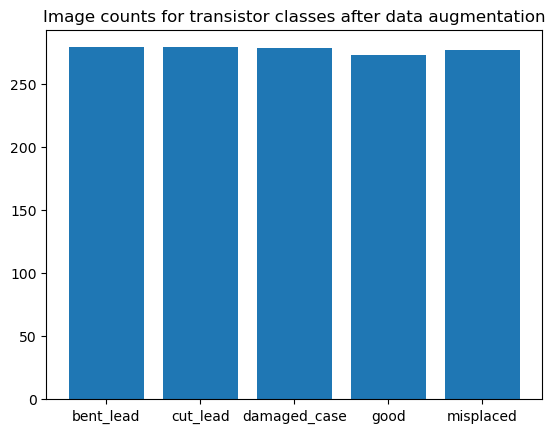

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

class_counts= get_class_counts_split('transistor', ['bent_lead', 'cut_lead', 'damaged_case', 'good', 'misplaced'])

#sns.countplot(class_counts);
plt.bar(['bent_lead', 'cut_lead', 'damaged_case', 'good', 'misplaced'], class_counts)
plt.title('Image counts for transistor classes after data augmentation');


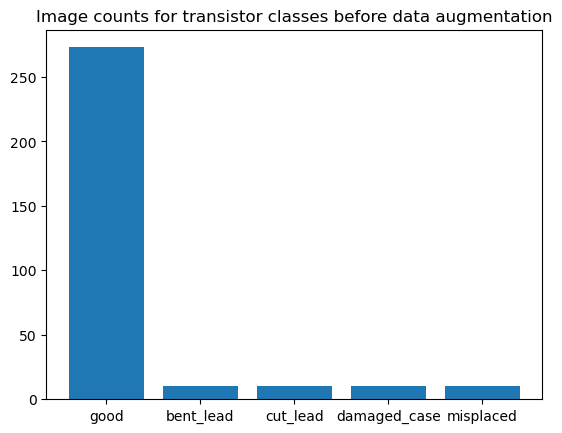

In [37]:
classes, counts = get_class_counts_MVTec('transistor')

plt.bar(classes, counts)
plt.title('Image counts for transistor classes before data augmentation');


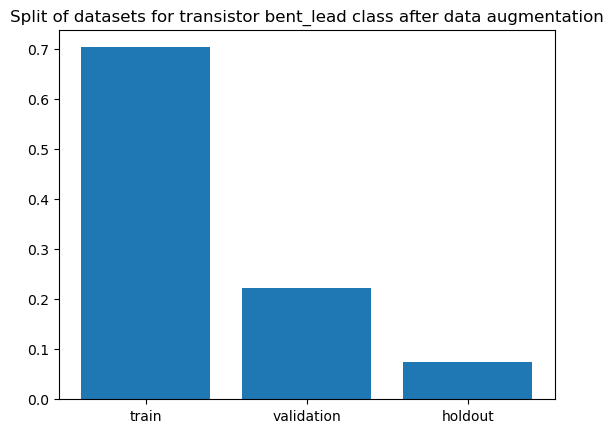

In [48]:
def get_dataset_split_counts(obj: str, cl: str):
    img_counts = []
    datasets = ['train', 'validation', 'holdout']
    img_counts = []
    for dataset in datasets:
        dirpath = f'/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation/{obj}/{dataset}/{cl}'
        img_files = [f for f in Path(dirpath).rglob('*.png') if f.is_file()]
        file_count = len(img_files)
        img_counts.append(file_count)

    return datasets, img_counts

datasets, counts = get_dataset_split_counts('transistor', 'bent_lead')
count_frac = [count/sum(counts) for count in counts]
plt.bar(datasets, count_frac)
plt.title('Split of datasets for transistor bent_lead class after data augmentation');
